# 06 — Confidence thresholds for the 18-class rock classifier

This notebook evaluates the saved **ConvNeXt-Tiny 18-class model**. Sections
**1–10** analyze the validation split at thresholds **0.50, 0.60, 0.70, 0.75,
0.80, 0.85, and 0.90**. Section **11** evaluates the test split using fixed
thresholds: **0.75 for the main accuracy result** and **0.90 for label review**.

At threshold `t`, an image is **accepted when its highest softmax probability is
greater than or equal to `t`**. The other images are rejected for review. The
model's predicted class does not change when the threshold changes.

**Run:** select the project's `Python (ML_dayo)` kernel (or an environment with
the project requirements installed), then run all cells from top to bottom.
No earlier notebook needs to be running. The existing dataset and crop functions
are imported from `modular.data_setup`; all new analysis functions are defined here.
The notebook loads local model weights and does not train or download a model.

**Outputs:** an image-level DataFrame `df`, an overall `threshold_results` table,
results for each of the 18 true classes, a comparison plot, high-confidence
disagreement review tables, and CSV/JSON exports
under `results/06_Threshold/validation/`. Section 11 adds separate test tables
and exports under `results/06_Threshold/test/`. Re-running a section replaces
its corresponding exports.

## 1. Imports and configuration

The full checkpoint is used because it stores the model weights **and the class
names/index mapping**. Its filename is the merged 18-class, trial-21, epoch-11
checkpoint saved by notebook 03. The validation path is the same merged PPL split
used in notebooks 03 and 05; the space in `carbonate_1223 _merge` is intentional.

CUDA is used when available, otherwise inference runs on CPU. `NUM_WORKERS = 0`
keeps the loader simple to run inside a notebook. Lower `BATCH_SIZE` if memory is
limited. All validation images are evaluated, with no sampling or augmentation.

In [1]:
from pathlib import Path
from functools import partial
from time import perf_counter
from datetime import datetime, timezone
import json
import sys

import torch
import torchvision
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# Find the project when launched from its root or a folder inside it.
PROJECT_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "modular" / "data_setup.py").is_file() and (p / "models").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook from the Rock_Classification project.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modular.data_setup import RockClassificationDataset, remove_bottom_annotation

MODEL_PATH = PROJECT_ROOT / "models/FULL_MERGED_18_classes_convnext_tiny_adamw_trial21_epoch11.pth"
VAL_DIR = PROJECT_ROOT / "data/carbonate_1223 _merge/PPL-1223/val"
OUTPUT_DIR = PROJECT_ROOT / "results/06_Threshold/validation"

THRESHOLDS = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]
DETAIL_THRESHOLD = 0.80  # Display choice only; this is not an automatically selected threshold.
BATCH_SIZE = 32
NUM_WORKERS = 0
CPU_THREADS = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    torch.set_num_threads(CPU_THREADS)

if not MODEL_PATH.is_file():
    raise FileNotFoundError(MODEL_PATH)
if not VAL_DIR.is_dir():
    raise FileNotFoundError(VAL_DIR)

print(f"Device: {device}")
print(f"Checkpoint: {MODEL_PATH.name}")
print(f"Validation folder: {VAL_DIR}")

Device: cpu
Checkpoint: FULL_MERGED_18_classes_convnext_tiny_adamw_trial21_epoch11.pth
Validation folder: /home/d/Documents/Other_projects/Rock_Classification/data/carbonate_1223 _merge/PPL-1223/val


## 2. Load the checkpoint and verify the exact class order

Model output column `i` represents `class_names[i]`, with **zero-based indices
0 through 17**. An incorrect order would silently attach the wrong class name to
a probability. We therefore require the checkpoint names and `class_to_idx` to
match the explicit order below, then check the dataset mapping in the next step.

`weights=None` constructs the architecture without downloading pretrained weights.
`load_state_dict(..., strict=True)` restores the trained parameters from disk.
`model.eval()` enables evaluation behavior; gradient computation is disabled in
the inference loop later.

In [2]:
EXPECTED_CLASS_NAMES = [
    "class2_class13", "class3", "class4", "class5",
    "class6", "class7", "class8", "class9",
    "class10", "class11", "class12", "class14",
    "class15", "class16", "class17", "class18_class19",
    "class20", "class21_class22",
]

checkpoint = torch.load(MODEL_PATH, map_location="cpu", weights_only=True)
class_names = list(checkpoint["class_names"])
class_to_idx = {name: index for index, name in enumerate(class_names)}

if checkpoint["model_name"] != "convnext_tiny":
    raise ValueError("The selected checkpoint is not a ConvNeXt-Tiny model.")
if checkpoint["num_classes"] != 18 or class_names != EXPECTED_CLASS_NAMES:
    raise ValueError("Checkpoint classes do not match the expected 18-class order.")
if checkpoint["class_to_idx"] != class_to_idx:
    raise ValueError("Checkpoint class_to_idx does not match its class_names order.")
if checkpoint["remove_bottom_pixels"] != 90:
    raise ValueError("Checkpoint crop size differs from the expected 90 pixels.")
if checkpoint["pretrained_weights"] != str(ConvNeXt_Tiny_Weights.IMAGENET1K_V1):
    raise ValueError("Checkpoint preprocessing differs from the expected ImageNet V1 preset.")

model = convnext_tiny(weights=None, num_classes=len(class_names))
model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model = model.to(device)
model.eval()

display(pd.DataFrame({"class_index": range(len(class_names)), "class_name": class_names}))
print("Checkpoint class order verified: all 18 classes match.")

Checkpoint class order verified: all 18 classes match.


,class_index,class_name
0,0,class2_class13
1,1,class3
2,2,class4
3,3,class5
4,4,class6
5,5,class7
6,6,class8
7,7,class9
8,8,class10
9,9,class11


## 3. Prepare the validation dataset

Preprocessing matches the evaluation pipeline in notebooks 03 and 05:

1. Load each image as RGB using `RockClassificationDataset`.
2. Remove the bottom **90 pixels**, where the annotation appears.
3. Apply the `ConvNeXt_Tiny_Weights.IMAGENET1K_V1` evaluation preset: resize,
   center crop, tensor conversion, and ImageNet normalization. Its exact settings
   are printed below.

`shuffle=False` and `drop_last=False` preserve dataset order and include the final
partial batch. This allows each prediction to be matched to its source image path.
The dataset assigns labels from class folders using the project's numeric sort.

In [3]:
val_transform = transforms.Compose([
    transforms.Lambda(partial(remove_bottom_annotation, pixels=90)),
    ConvNeXt_Tiny_Weights.IMAGENET1K_V1.transforms(),
])

val_dataset = RockClassificationDataset(root_dir=VAL_DIR, image_transform=val_transform)
if val_dataset.classes != class_names or val_dataset.class_to_idx != class_to_idx:
    raise ValueError("Validation labels do not match the saved model's class order.")
if len(val_dataset) == 0:
    raise ValueError("No validation images were found.")

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

validation_class_counts = pd.DataFrame({
    "class_index": range(len(class_names)),
    "class_name": class_names,
    "validation_images": pd.Series([label for _, label in val_dataset.samples])
        .value_counts().reindex(range(len(class_names)), fill_value=0).to_numpy(),
})
print(val_transform)
print(f"Validation images: {len(val_dataset):,} across {len(class_names)} classes")
display(validation_class_counts)

Compose(
    Lambda()
    ImageClassification(
    crop_size=[224]
    resize_size=[236]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)
)
Validation images: 5,994 across 18 classes


,class_index,class_name,validation_images
0,0,class2_class13,1083
1,1,class3,165
2,2,class4,7
3,3,class5,3
4,4,class6,72
5,5,class7,485
6,6,class8,29
7,7,class9,147
8,8,class10,204
9,9,class11,39


## 4. Run inference once and build the image-level table

For each batch, softmax converts the 18 logits into probabilities. Taking the
maximum gives the **confidence** and **predicted class index**. Only the winning
probability is retained; this is sufficient for the requested threshold analysis.

The first four columns match the requested example:

| Column | Meaning |
| --- | --- |
| `confidence` | Largest softmax probability, between 0 and 1 |
| `prediction` | Predicted class index, 0–17 |
| `true_label` | Ground-truth class index from the validation folder |
| `correct` | Whether `prediction == true_label` |
| `predicted_class`, `true_class` | Readable names for those indices |
| `image_path` | Source image path relative to the project root |

The checks after inference ensure that every validation image has exactly one
result and that labels still align with the dataset paths. Re-run this cell only
when the model, data, or preprocessing changes; different thresholds can reuse `df`.

In [4]:
model.eval()
all_confidences = []
all_predictions = []
all_labels = []
started_at_utc = datetime.now(timezone.utc).isoformat()
start_time = perf_counter()

with torch.inference_mode():
    for batch_number, (images, labels) in enumerate(val_loader, start=1):
        images = images.to(device, non_blocking=(device.type == "cuda"))
        outputs = model(images)
        if outputs.shape != (images.shape[0], len(class_names)):
            raise ValueError(f"Unexpected model output shape: {outputs.shape}")
        if not torch.isfinite(outputs).all().item():
            raise ValueError("Model returned non-finite logits.")

        probabilities = torch.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, dim=1)

        all_confidences.extend(confidences.cpu().tolist())
        all_predictions.extend(predictions.cpu().tolist())
        all_labels.extend(labels.tolist())  # Labels stay on CPU; they are only recorded.

        if batch_number == 1 or batch_number % 20 == 0 or batch_number == len(val_loader):
            print(f"Processed {len(all_labels):,}/{len(val_dataset):,} validation images")

inference_seconds = perf_counter() - start_time
df = pd.DataFrame({
    "confidence": all_confidences,
    "prediction": all_predictions,
    "true_label": all_labels,
})
df["correct"] = df["prediction"] == df["true_label"]
df["predicted_class"] = df["prediction"].map(dict(enumerate(class_names)))
df["true_class"] = df["true_label"].map(dict(enumerate(class_names)))

expected_labels = [label for _, label in val_dataset.samples]
if len(df) != len(val_dataset) or df["true_label"].tolist() != expected_labels:
    raise ValueError("Predictions and dataset image order do not align.")
if not df["confidence"].between(0, 1).all():
    raise ValueError("Invalid confidence values were produced.")
df["image_path"] = [str(path.relative_to(PROJECT_ROOT)) for path, _ in val_dataset.samples]

baseline_accuracy = float(df["correct"].mean())
print(f"Inference completed in {inference_seconds:.1f} seconds")
print(f"Accuracy on all validation images (no rejection): {baseline_accuracy:.2%}")
display(df.head())

Processed 32/5,994 validation images
Processed 640/5,994 validation images
Processed 1,280/5,994 validation images
Processed 1,920/5,994 validation images
Processed 2,560/5,994 validation images
Processed 3,200/5,994 validation images
Processed 3,840/5,994 validation images
Processed 4,480/5,994 validation images
Processed 5,120/5,994 validation images
Processed 5,760/5,994 validation images
Processed 5,994/5,994 validation images
Inference completed in 174.4 seconds
Accuracy on all validation images (no rejection): 55.71%


,confidence,prediction,true_label,correct,predicted_class,true_class,image_path
0,0.783201,10,0,False,class12,class2_class13,data/carbonate_1223 _merge/PPL-1223/val/class2...
1,0.809231,15,0,False,class18_class19,class2_class13,data/carbonate_1223 _merge/PPL-1223/val/class2...
2,0.904317,0,0,True,class2_class13,class2_class13,data/carbonate_1223 _merge/PPL-1223/val/class2...
3,0.986265,0,0,True,class2_class13,class2_class13,data/carbonate_1223 _merge/PPL-1223/val/class2...
4,0.724171,0,0,True,class2_class13,class2_class13,data/carbonate_1223 _merge/PPL-1223/val/class2...


## 5. Compare confidence thresholds

For each threshold:

- **Accepted images:** images with `confidence >= threshold` (the boundary is included).
- **Coverage:** `accepted_images / total_images`, the fraction of images kept.
- **Accuracy:** correct predictions among **accepted images only**, divided by
  `accepted_images`. Rejected images do not enter this accuracy calculation.
- **Rejected images:** `total_images - accepted_images`.

The `coverage` and `accuracy` columns are fractions: `0.80` means 80%.
When no image is accepted, coverage is `0.0` and accuracy is `NaN` (undefined),
not zero. The helper also handles an empty class subset the same way.

In [5]:
def summarize_thresholds(predictions_df, thresholds):
    """Calculate coverage and accepted-only accuracy for each inclusive threshold.

    predictions_df must contain confidence (0–1) and correct (boolean) columns.
    An empty input or an empty accepted subset has undefined accuracy (NaN).
    """
    total_images = len(predictions_df)
    results = []
    for threshold in thresholds:
        if not 0 <= threshold <= 1:
            raise ValueError("Thresholds must be between 0 and 1.")
        accepted = predictions_df[predictions_df["confidence"] >= threshold]
        accepted_images = len(accepted)
        results.append({
            "threshold": float(threshold),
            "accepted_images": accepted_images,
            "total_images": total_images,
            "coverage": accepted_images / total_images if total_images else 0.0,
            "accuracy": float(accepted["correct"].mean()) if accepted_images else float("nan"),
            "rejected_images": total_images - accepted_images,
            "correct_accepted_images": int(accepted["correct"].sum()),
        })
    return pd.DataFrame(results)


threshold_results = summarize_thresholds(df, THRESHOLDS)
display(threshold_results.round({"coverage": 4, "accuracy": 4}))

,threshold,accepted_images,total_images,coverage,accuracy,rejected_images,correct_accepted_images
0,0.50,4707,5994,0.7853,0.6170,1287,2904
1,0.60,3870,5994,0.6456,0.6556,2124,2537
2,0.70,3123,5994,0.5210,0.6907,2871,2157
3,0.75,2740,5994,0.4571,0.7095,3254,1944
4,0.80,2360,5994,0.3937,0.7237,3634,1708
5,0.85,1933,5994,0.3225,0.7455,4061,1441
6,0.90,1486,5994,0.2479,0.7719,4508,1147


## 6. Plot the coverage–accuracy tradeoff

Raising the threshold can reduce the number of predictions you accept. Coverage
cannot increase as the threshold rises, but accepted accuracy is **not guaranteed**
to improve at every step. The dashed line shows accuracy when every validation
image is included. A high accepted accuracy with very low coverage describes only
a small subset of images.

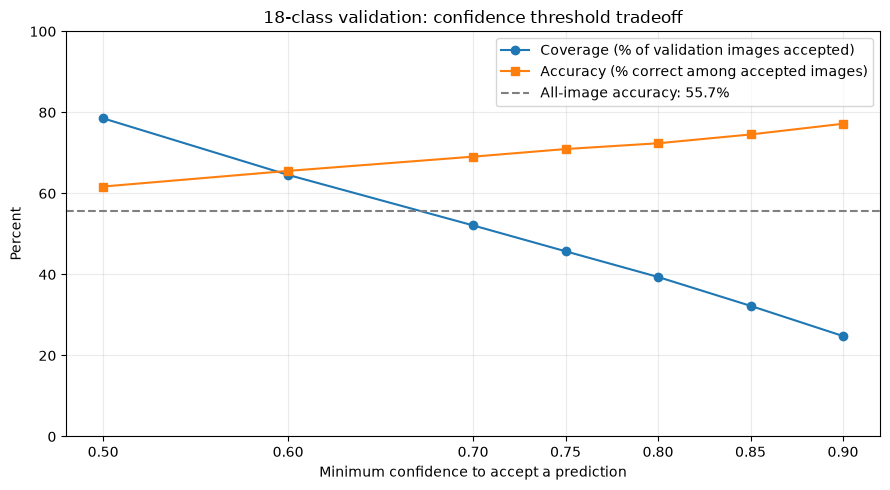

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_results["threshold"], threshold_results["coverage"] * 100,
        marker="o", label="Coverage (% of validation images accepted)")
ax.plot(threshold_results["threshold"], threshold_results["accuracy"] * 100,
        marker="s", label="Accuracy (% correct among accepted images)")
ax.axhline(baseline_accuracy * 100, color="gray", linestyle="--",
           label=f"All-image accuracy: {baseline_accuracy:.1%}")
ax.set(title="18-class validation: confidence threshold tradeoff",
       xlabel="Minimum confidence to accept a prediction", ylabel="Percent",
       ylim=(0, 100), xticks=THRESHOLDS)
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
plt.show()

## 7. Check all 18 classes separately

Overall accuracy is weighted by the number of images in each class. A threshold
can therefore look useful overall while rejecting most images from a smaller or
more difficult class. This table groups by the **true class**, not the predicted
class, and includes all 18 classes at every requested threshold.

Within each true class, `total_images` is its validation support, `coverage` is
the fraction of that class's images accepted, and `accuracy` is the fraction
correct among that class's accepted images. This is **not precision grouped by
predicted class**, and it excludes rejected examples. `baseline_accuracy` shows
the correct fraction for that true class before applying a threshold.

`per_class_results` contains every class/threshold combination. The display below
shows `DETAIL_THRESHOLD` (default 0.80) for readability; this is an inspection
setting, not a recommendation. Change it to any value in `THRESHOLDS` and re-run
this cell to inspect another threshold.

In [7]:
per_class_tables = []
for class_index, class_name in enumerate(class_names):
    class_df = df[df["true_label"] == class_index]
    class_table = summarize_thresholds(class_df, THRESHOLDS)
    class_table.insert(0, "class_index", class_index)
    class_table.insert(1, "class_name", class_name)
    class_table["baseline_accuracy"] = float(class_df["correct"].mean()) if len(class_df) else float("nan")
    per_class_tables.append(class_table)

per_class_results = pd.concat(per_class_tables, ignore_index=True)
if DETAIL_THRESHOLD not in THRESHOLDS:
    raise ValueError("Choose DETAIL_THRESHOLD from THRESHOLDS.")
print(f"Per-true-class results at confidence >= {DETAIL_THRESHOLD:.2f}")
display(
    per_class_results.loc[per_class_results["threshold"] == DETAIL_THRESHOLD]
    .reset_index(drop=True)
    .round({"coverage": 4, "accuracy": 4, "baseline_accuracy": 4})
)

Per-true-class results at confidence >= 0.80


,class_index,class_name,threshold,accepted_images,total_images,coverage,accuracy,rejected_images,correct_accepted_images,baseline_accuracy
0,0,class2_class13,0.8,705,1083,0.6510,0.9149,378,645,0.7608
1,1,class3,0.8,67,165,0.4061,0.6119,98,41,0.3576
2,2,class4,0.8,1,7,0.1429,0.0000,6,0,0.1429
3,3,class5,0.8,3,3,1.0000,1.0000,0,3,1.0000
4,4,class6,0.8,27,72,0.3750,0.5556,45,15,0.3333
5,5,class7,0.8,196,485,0.4041,0.7041,289,138,0.5361
6,6,class8,0.8,15,29,0.5172,0.4000,14,6,0.3793
7,7,class9,0.8,86,147,0.5850,0.6860,61,59,0.5374
8,8,class10,0.8,76,204,0.3725,0.6184,128,47,0.3873
9,9,class11,0.8,21,39,0.5385,0.8571,18,18,0.5897


## 8. Export results and record the run settings

The exports retain full numeric precision; rounding above affects display only.

- `validation_predictions.csv`: one row per validation image, including its path.
- `validation_threshold_results.csv`: the seven overall threshold comparisons.
- `validation_per_class_threshold_results.csv`: all 18 classes at every threshold.
- `validation_threshold_tradeoff.png`: the comparison chart.
- `run_metadata.json`: checkpoint filename, class order, preprocessing, split,
  inference settings, software versions, and baseline accuracy for this run.

The exports are separate from the model and source data. Re-running this section
updates the same output filenames.

In [8]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
threshold_results.to_csv(OUTPUT_DIR / "validation_threshold_results.csv", index=False)
per_class_results.to_csv(OUTPUT_DIR / "validation_per_class_threshold_results.csv", index=False)
fig.savefig(OUTPUT_DIR / "validation_threshold_tradeoff.png", dpi=160, bbox_inches="tight")

run_metadata = {
    "started_at_utc": started_at_utc,
    "split": "validation",
    "dataset_path": str(VAL_DIR.relative_to(PROJECT_ROOT)),
    "checkpoint_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
    "checkpoint_size_bytes": MODEL_PATH.stat().st_size,
    "model_name": checkpoint["model_name"],
    "num_classes": len(class_names),
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "preprocessing": {"remove_bottom_pixels": 90, "preset": str(ConvNeXt_Tiny_Weights.IMAGENET1K_V1)},
    "thresholds": THRESHOLDS,
    "acceptance_rule": "confidence >= threshold",
    "total_images": len(df),
    "baseline_accuracy": baseline_accuracy,
    "device": str(device),
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "cpu_threads": torch.get_num_threads(),
    "inference_seconds": inference_seconds,
    "torch_version": str(torch.__version__),
    "torchvision_version": str(torchvision.__version__),
    "pandas_version": pd.__version__,
}
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(run_metadata, indent=2) + "\n")
print(f"Saved validation analysis to: {OUTPUT_DIR}")

Saved validation analysis to: /home/d/Documents/Other_projects/Rock_Classification/results/06_Threshold/validation


## 9. High-confidence disagreement analysis

This section finds validation images for which the model is confident **and
disagrees with the provided dataset label**, then checks whether the same
label-to-prediction pairs recur. It reuses `df`; no additional model inference
is needed when changing the cutoffs below.

Here, `true_class` means the **provided folder label**, and `correct` means
agreement with that label. These names are retained for compatibility with
the earlier analysis. `high_conf_errors` contains candidate cases for review,
not independently confirmed model errors or label errors. A frequent,
confident disagreement is a useful audit lead; visual review must determine
whether the label, the prediction, or the class definition is the problem.

**Reuse saved predictions after restarting the kernel:** run section 1, then
load `df` with the following before running this section:

```python
df = pd.read_csv(OUTPUT_DIR / "validation_predictions.csv", float_precision="round_trip")
```

### 9.1. List the most confident disagreements

Start at confidence **>= 0.75**, sort from highest to lowest, and display the
first 30 images. `image_path` is relative to `PROJECT_ROOT`, so the full path
for an image is `PROJECT_ROOT / image_path`. The complete list is retained in
`high_conf_errors`, even though only 30 rows are displayed.

In [9]:
HIGH_CONF_THRESHOLD = 0.75
if not 0 <= HIGH_CONF_THRESHOLD <= 1:
    raise ValueError("HIGH_CONF_THRESHOLD must be between 0 and 1.")

high_conf_errors = df[
    (df["confidence"] >= HIGH_CONF_THRESHOLD) & (~df["correct"])
].copy()
high_conf_errors = high_conf_errors.sort_values(
    "confidence", ascending=False, kind="stable"
)

review_columns = ["confidence", "predicted_class", "true_class", "image_path"]
print(f"Validation images: {len(df):,}")
print(f"Disagreements with confidence >= {HIGH_CONF_THRESHOLD:.2f}: {len(high_conf_errors):,}")
with pd.option_context("display.max_rows", 30, "display.max_colwidth", None):
    display(high_conf_errors[review_columns].head(30))

Validation images: 5,994
Disagreements with confidence >= 0.75: 796


,confidence,predicted_class,true_class,image_path
1062,0.999858,class17,class2_class13,data/carbonate_1223 _merge/PPL-1223/val/class2_class13/class2__Bioclastics.829.jpg
1061,0.999657,class17,class2_class13,data/carbonate_1223 _merge/PPL-1223/val/class2_class13/class2__Bioclastics.828.jpg
62,0.998804,class20,class2_class13,data/carbonate_1223 _merge/PPL-1223/val/class2_class13/class13__Micritic_limestone.178.jpg
4877,0.998685,class15,class21_class22,data/carbonate_1223 _merge/PPL-1223/val/class21_class22/class21__Thrombotolite.869_ARS.jpg
2416,0.998502,class11,class12,data/carbonate_1223 _merge/PPL-1223/val/class12/Micritic_dolomite.425.jpg
4680,0.998243,class9,class21_class22,data/carbonate_1223 _merge/PPL-1223/val/class21_class22/class21__Thrombotolite.610.jpg
3244,0.997119,class20,class18_class19,data/carbonate_1223 _merge/PPL-1223/val/class18_class19/class19__Stromatolite.218.jpg
4764,0.997019,class9,class21_class22,data/carbonate_1223 _merge/PPL-1223/val/class21_class22/class21__Thrombotolite.717.jpg
4478,0.996908,class9,class21_class22,data/carbonate_1223 _merge/PPL-1223/val/class21_class22/class21__Thrombotolite.369.jpg
4768,0.996518,class9,class21_class22,data/carbonate_1223 _merge/PPL-1223/val/class21_class22/class21__Thrombotolite.721.jpg


### 9.2. Find recurring provided-label → model-prediction pairs

The direction matters: `class12 → class2_class13` is a different pair from
`class2_class13 → class12`. The first column is always the provided label.
The table displays the 20 pairs with the highest `fraction_of_provided_class`,
sorted from highest to lowest; `error_pairs` retains them all. Ties are broken
by descending count, then class names.
It uses the same columns as the stricter table in section 9.3:

- `count`: number of disagreements for this pair at `HIGH_CONF_THRESHOLD` (default 0.75).
- `min_confidence`, `mean_confidence`: confidence of those selected predictions.
- `provided_class_images`: all validation images with that provided label.
- `fraction_of_provided_class`: `count / provided_class_images`, a fraction from 0 to 1.
  The denominator includes all images of the provided class, regardless of
  confidence or agreement, so the rate helps interpret counts from classes of different sizes.

Only the displayed confidence values and fractions are rounded to four decimal
places; the DataFrame and CSV export retain full precision.

In [14]:
error_pairs = (
    high_conf_errors
    .groupby(["true_class", "predicted_class"])
    .agg(
        count=("confidence", "size"),
        min_confidence=("confidence", "min"),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)
error_pairs["provided_class_images"] = error_pairs["true_class"].map(
    df["true_class"].value_counts()
)
error_pairs["fraction_of_provided_class"] = (
    error_pairs["count"] / error_pairs["provided_class_images"]
)
error_pairs = error_pairs.sort_values(
    ["fraction_of_provided_class", "count", "true_class", "predicted_class"],
    ascending=[False, False, True, True],
).reset_index(drop=True)

print(f"Disagreement pairs ranked by fraction of provided class at confidence >= {HIGH_CONF_THRESHOLD:.2f}")
display(error_pairs.head(20).round({
    "min_confidence": 4, "mean_confidence": 4, "fraction_of_provided_class": 4
}))

Disagreement pairs ranked by fraction of provided class at confidence >= 0.75


,true_class,predicted_class,count,min_confidence,mean_confidence,provided_class_images,fraction_of_provided_class
0,class4,class11,1,0.8663,0.8663,7,0.1429
1,class8,class2_class13,4,0.8295,0.9019,29,0.1379
2,class9,class21_class22,20,0.7511,0.8427,147,0.1361
3,class3,class21_class22,19,0.7702,0.8813,165,0.1152
4,class16,class21_class22,2,0.7901,0.8227,20,0.1000
5,class6,class21_class22,6,0.8543,0.9030,72,0.0833
6,class11,class21_class22,3,0.7520,0.8224,39,0.0769
7,class8,class12,2,0.8734,0.8750,29,0.0690
8,class8,class21_class22,2,0.8033,0.8164,29,0.0690
9,class17,class21_class22,2,0.7851,0.7889,34,0.0588


### 9.3. Look for repeated disagreements at confidence >= 0.90

This is a separate filter on the full validation `df`, so its results do not
depend on the 0.75 cutoff in section 9.1. For example, to look for **at least
70 images sharing the same provided label and predicted label, each with
confidence >= 0.90**, use the defaults below.

`strict_error_pairs` lists all pairs at this stricter cutoff, sorted by
`fraction_of_provided_class` from highest to lowest. Ties are broken by
descending count, then class names. The display shows the top 20 pairs with:

- `count`: number of qualifying disagreements for that directed pair.
- `min_confidence`, `mean_confidence`: confidence of the selected predictions.
- `provided_class_images`: all validation images with that provided label.
- `fraction_of_provided_class`: `count / provided_class_images`, a fraction
  from 0 to 1. Its denominator includes all images of that provided class,
  regardless of confidence or agreement.

`strong_pair_candidates` keeps pairs whose count reaches `MIN_PAIR_COUNT`.
An empty shortlist means no pair meets those settings; it does not establish
that the labels are clean. Both confidence boundaries are inclusive (`>=`).

In [15]:
PAIR_CONF_THRESHOLD = 0.90
MIN_PAIR_COUNT = 70
if not 0 <= PAIR_CONF_THRESHOLD <= 1:
    raise ValueError("PAIR_CONF_THRESHOLD must be between 0 and 1.")
if not isinstance(MIN_PAIR_COUNT, int) or MIN_PAIR_COUNT < 1:
    raise ValueError("MIN_PAIR_COUNT must be a positive integer.")

strict_disagreements = df[
    (df["confidence"] >= PAIR_CONF_THRESHOLD) & (~df["correct"])
].copy()
strict_error_pairs = (
    strict_disagreements
    .groupby(["true_class", "predicted_class"])
    .agg(
        count=("confidence", "size"),
        min_confidence=("confidence", "min"),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)
strict_error_pairs["provided_class_images"] = strict_error_pairs["true_class"].map(
    df["true_class"].value_counts()
)
strict_error_pairs["fraction_of_provided_class"] = (
    strict_error_pairs["count"] / strict_error_pairs["provided_class_images"]
)
strict_error_pairs = strict_error_pairs.sort_values(
    ["fraction_of_provided_class", "count", "true_class", "predicted_class"],
    ascending=[False, False, True, True],
).reset_index(drop=True)
strong_pair_candidates = strict_error_pairs[
    strict_error_pairs["count"] >= MIN_PAIR_COUNT
].copy()

print(f"Disagreements with confidence >= {PAIR_CONF_THRESHOLD:.2f}: {len(strict_disagreements):,}")
print("Top 20 directed pairs by fraction of provided class:")
display(strict_error_pairs.head(20).round({
    "min_confidence": 4, "mean_confidence": 4, "fraction_of_provided_class": 4
}))

print(f"Pairs with at least {MIN_PAIR_COUNT} qualifying images: {len(strong_pair_candidates)}")
if strong_pair_candidates.empty:
    print("No pair meets both settings. Inspect the top pairs above or change the settings.")
else:
    display(strong_pair_candidates)

Disagreements with confidence >= 0.90: 339
Top 20 directed pairs by fraction of provided class:
Pairs with at least 70 qualifying images: 0
No pair meets both settings. Inspect the top pairs above or change the settings.


,true_class,predicted_class,count,min_confidence,mean_confidence,provided_class_images,fraction_of_provided_class
0,class3,class21_class22,8,0.9126,0.9411,165,0.0485
1,class6,class21_class22,3,0.9123,0.9276,72,0.0417
2,class8,class10,1,0.9523,0.9523,29,0.0345
3,class8,class2_class13,1,0.9927,0.9927,29,0.0345
4,class10,class2_class13,7,0.9169,0.9549,204,0.0343
5,class9,class21_class22,4,0.9087,0.9294,147,0.0272
6,class11,class10,1,0.9674,0.9674,39,0.0256
7,class11,class21_class22,1,0.9418,0.9418,39,0.0256
8,class21_class22,class9,55,0.9007,0.9579,2191,0.0251
9,class3,class10,4,0.9163,0.9432,165,0.0242


### 9.4. Save the full review lists

These exports use the same validation output folder as section 8. They contain
complete tables, rather than just the displayed top 30 images or top 20 pairs.
The JSON file records the cutoffs so the CSVs can be interpreted later.
Changing a cutoff and re-running sections 9.1–9.4 replaces these exports.

- `validation_high_conf_disagreements.csv`: the image-level review shortlist.
- `validation_disagreement_pairs.csv`: all recurring pairs at `HIGH_CONF_THRESHOLD`.
- `validation_strict_disagreement_pairs.csv`: all pairs at `PAIR_CONF_THRESHOLD`.
- `validation_strong_pair_candidates.csv`: strict pairs meeting `MIN_PAIR_COUNT`.
- `disagreement_analysis_settings.json`: the settings and number of cases.

To review a particular strict pair, filter `strict_disagreements` on
`true_class` and `predicted_class`, then sort by `confidence`. Keep the original
labels and record any independent review decisions separately.

In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
high_conf_errors.to_csv(OUTPUT_DIR / "validation_high_conf_disagreements.csv", index=False)
error_pairs.to_csv(OUTPUT_DIR / "validation_disagreement_pairs.csv", index=False)
strict_error_pairs.to_csv(OUTPUT_DIR / "validation_strict_disagreement_pairs.csv", index=False)
strong_pair_candidates.to_csv(OUTPUT_DIR / "validation_strong_pair_candidates.csv", index=False)

disagreement_settings = {
    "split": "validation",
    "source_predictions": "validation_predictions.csv",
    "high_confidence_threshold": HIGH_CONF_THRESHOLD,
    "pair_confidence_threshold": PAIR_CONF_THRESHOLD,
    "minimum_pair_count": MIN_PAIR_COUNT,
    "selection_rule": "confidence >= cutoff and prediction != provided label",
    "pair_direction": "provided label -> model prediction",
    "total_validation_images": len(df),
    "high_confidence_disagreements": len(high_conf_errors),
    "strict_disagreements": len(strict_disagreements),
    "strong_pair_candidates": len(strong_pair_candidates),
}
(OUTPUT_DIR / "disagreement_analysis_settings.json").write_text(
    json.dumps(disagreement_settings, indent=2) + "\n"
)
print(f"Saved disagreement review tables to: {OUTPUT_DIR}")

Saved disagreement review tables to: /home/d/Documents/Other_projects/Rock_Classification/results/06_Threshold/validation


## 10. Interpret the results and choose a threshold

Use `threshold_results` to compare accepted accuracy with how many images remain
usable. Then inspect `per_class_results` to see which categories lose coverage.
There is no universally best threshold: choose the accuracy/coverage balance
needed for the intended use, and account for the number of accepted examples.

**Confidence is a model score, not a guarantee of correctness.** A softmax score
of 0.90 does not by itself establish a 90% chance that the prediction is correct.
The observed validation accuracy measures how often accepted predictions were
correct on this split.

Use validation results to decide the thresholds and keep those decisions fixed
for test evaluation. Section 11 applies the chosen thresholds of 0.75 and 0.90
to the test split, separately from the validation analysis above.
The validation split was also used during model development, so these results
are for threshold selection and inspection, not a final independent performance
estimate. Low-confidence images remain in `df` for review; rejection does not
create a nineteenth class or change the trained model.

## 11. Test evaluation and high-confidence disagreement analysis

> When my model is reasonably confident, how often is it correct on unseen test data?

The primary answer is **accuracy among test images with confidence >= 0.75**,
reported alongside **coverage**: how many of all test images meet that cutoff.
A separate **0.90** cutoff identifies confident disagreements for label review.
These thresholds are fixed before this test run; this section does not search
for a better threshold on the test results.

The model, 18-class order, RGB loading, bottom-90-pixel crop, and ConvNeXt
evaluation preset match the validation analysis. Only the input split changes.
`test_df` and all test exports are separate from validation `df` and its exports.

**Run this section without repeating validation inference:** run sections 1
and 2 to import dependencies and load the checkpoint, then run section 11.
All new helper functions needed for this section are defined below.

**Meaning of “correct”:** agreement with the provided test-folder label.
Disagreements at either cutoff are review candidates, not confirmed label
errors. This evaluates the designated test split; it does not verify that
images are independent of the training set or that the split has never been
inspected previously. Notebook 03 already contains a test-evaluation section.

### 11.1. Fixed thresholds and test dataset

In [16]:
MAIN_THRESHOLD = 0.75
LABEL_REVIEW_THRESHOLD = 0.90
TEST_DIR = PROJECT_ROOT / "data/carbonate_1223 _merge/PPL-1223/test"
TEST_OUTPUT_DIR = PROJECT_ROOT / "results/06_Threshold/test"

if not 0 <= MAIN_THRESHOLD <= LABEL_REVIEW_THRESHOLD <= 1:
    raise ValueError("Expected 0 <= MAIN_THRESHOLD <= LABEL_REVIEW_THRESHOLD <= 1.")
if not TEST_DIR.is_dir():
    raise FileNotFoundError(TEST_DIR)

test_transform = transforms.Compose([
    transforms.Lambda(partial(remove_bottom_annotation, pixels=90)),
    ConvNeXt_Tiny_Weights.IMAGENET1K_V1.transforms(),
])
test_dataset = RockClassificationDataset(root_dir=TEST_DIR, image_transform=test_transform)
if test_dataset.classes != class_names or test_dataset.class_to_idx != class_to_idx:
    raise ValueError("Test labels do not match the saved model's 18-class order.")
if len(test_dataset) == 0:
    raise ValueError("No test images were found.")

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)
test_class_counts = pd.DataFrame({
    "class_index": range(len(class_names)),
    "class_name": class_names,
    "test_images": pd.Series([label for _, label in test_dataset.samples])
        .value_counts().reindex(range(len(class_names)), fill_value=0).to_numpy(),
})
print(f"Test images: {len(test_dataset):,} across {len(class_names)} classes")
print(f"Main threshold: {MAIN_THRESHOLD:.2f}; label-review threshold: {LABEL_REVIEW_THRESHOLD:.2f}")
display(test_class_counts)

Test images: 2,786 across 18 classes
Main threshold: 0.75; label-review threshold: 0.90


,class_index,class_name,test_images
0,0,class2_class13,431
1,1,class3,98
2,2,class4,9
3,3,class5,2
4,4,class6,25
5,5,class7,180
6,6,class8,14
7,7,class9,37
8,8,class10,58
9,9,class11,15


### 11.2. Predict every test image once

The model stays in evaluation mode, with gradients disabled. Every image is
included exactly once, and dataset order is preserved to attach the correct
image paths. `confidence` is the largest softmax probability and `prediction`
is its class index. The names `true_label` and `true_class` refer to the
provided dataset labels, which have not been independently audited here.

In [17]:
model.eval()
test_confidences = []
test_predictions = []
test_labels = []
test_started_at_utc = datetime.now(timezone.utc).isoformat()
test_start_time = perf_counter()

with torch.inference_mode():
    for test_batch_number, (test_images, test_batch_labels) in enumerate(test_loader, start=1):
        test_images = test_images.to(device, non_blocking=(device.type == "cuda"))
        test_outputs = model(test_images)
        if test_outputs.shape != (test_images.shape[0], len(class_names)):
            raise ValueError(f"Unexpected test output shape: {test_outputs.shape}")
        if not torch.isfinite(test_outputs).all().item():
            raise ValueError("Model returned non-finite test logits.")

        test_probabilities = torch.softmax(test_outputs, dim=1)
        test_batch_confidences, test_batch_predictions = torch.max(test_probabilities, dim=1)
        test_confidences.extend(test_batch_confidences.cpu().tolist())
        test_predictions.extend(test_batch_predictions.cpu().tolist())
        test_labels.extend(test_batch_labels.tolist())

        if test_batch_number == 1 or test_batch_number % 20 == 0 or test_batch_number == len(test_loader):
            print(f"Processed {len(test_labels):,}/{len(test_dataset):,} test images", flush=True)

test_inference_seconds = perf_counter() - test_start_time
test_df = pd.DataFrame({
    "confidence": test_confidences,
    "prediction": test_predictions,
    "true_label": test_labels,
})
test_df["correct"] = test_df["prediction"] == test_df["true_label"]
test_df["predicted_class"] = test_df["prediction"].map(dict(enumerate(class_names)))
test_df["true_class"] = test_df["true_label"].map(dict(enumerate(class_names)))

if len(test_df) != len(test_dataset) or test_labels != [label for _, label in test_dataset.samples]:
    raise ValueError("Test predictions and image paths do not align.")
if not test_df["confidence"].between(0, 1).all():
    raise ValueError("Invalid test confidence values were produced.")
test_df["image_path"] = [str(path.relative_to(PROJECT_ROOT)) for path, _ in test_dataset.samples]
test_baseline_accuracy = float(test_df["correct"].mean())
print(f"Test inference completed in {test_inference_seconds:.1f} seconds")
print(f"Test accuracy with no rejection: {test_baseline_accuracy:.2%}")
display(test_df.head())

Processed 32/2,786 test images
Processed 640/2,786 test images
Processed 1,280/2,786 test images
Processed 1,920/2,786 test images
Processed 2,560/2,786 test images
Processed 2,786/2,786 test images
Test inference completed in 82.8 seconds
Test accuracy with no rejection: 38.55%


,confidence,prediction,true_label,correct,predicted_class,true_class,image_path
0,0.559094,17,0,False,class21_class22,class2_class13,data/carbonate_1223 _merge/PPL-1223/test/class...
1,0.729643,0,0,True,class2_class13,class2_class13,data/carbonate_1223 _merge/PPL-1223/test/class...
2,0.751920,0,0,True,class2_class13,class2_class13,data/carbonate_1223 _merge/PPL-1223/test/class...
3,0.964144,8,0,False,class10,class2_class13,data/carbonate_1223 _merge/PPL-1223/test/class...
4,0.748871,10,0,False,class12,class2_class13,data/carbonate_1223 _merge/PPL-1223/test/class...


### 11.3. Answer the main question: accepted accuracy and coverage

- **Accuracy:** correct accepted predictions / accepted images.
- **Coverage:** accepted images / all test images.
- **Disagreement images:** accepted predictions that differ from provided labels.

An image is accepted when `confidence >= threshold`. Rejected images do not
enter accepted accuracy. If none is accepted, accuracy is undefined (`NaN`)
and coverage is zero. The 0.75 row is the main performance result; the 0.90
row describes the stricter label-review population. Both are shown as
fractions in the table (0.80 means 80%). This is accepted-only accuracy,
not macro F1 or the accuracy of the full dataset.

In [18]:
test_summary_rows = []
for test_purpose, test_threshold in [
    ("main_result", MAIN_THRESHOLD),
    ("label_review", LABEL_REVIEW_THRESHOLD),
]:
    test_accepted = test_df[test_df["confidence"] >= test_threshold]
    test_accepted_count = len(test_accepted)
    test_correct_count = int(test_accepted["correct"].sum())
    test_summary_rows.append({
        "purpose": test_purpose,
        "threshold": test_threshold,
        "accepted_images": test_accepted_count,
        "total_images": len(test_df),
        "coverage": test_accepted_count / len(test_df),
        "accuracy": test_correct_count / test_accepted_count if test_accepted_count else float("nan"),
        "correct_accepted_images": test_correct_count,
        "disagreement_images": test_accepted_count - test_correct_count,
        "rejected_images": len(test_df) - test_accepted_count,
    })
test_threshold_results = pd.DataFrame(test_summary_rows)
display(test_threshold_results.round({"coverage": 4, "accuracy": 4}))

test_main_result = test_threshold_results.iloc[0]
if test_main_result["accepted_images"]:
    print(
        f"At confidence >= {MAIN_THRESHOLD:.2f}, the model agrees with the provided test label "
        f"on {int(test_main_result['correct_accepted_images']):,} of "
        f"{int(test_main_result['accepted_images']):,} accepted images "
        f"({test_main_result['accuracy']:.2%} accuracy). "
        f"These accepted images cover {test_main_result['coverage']:.2%} of all test images."
    )
else:
    print("No test images meet the main threshold; accepted accuracy is undefined.")

At confidence >= 0.75, the model agrees with the provided test label on 440 of 923 accepted images (47.67% accuracy). These accepted images cover 33.13% of all test images.


,purpose,threshold,accepted_images,total_images,coverage,accuracy,correct_accepted_images,disagreement_images,rejected_images
0,main_result,0.75,923,2786,0.3313,0.4767,440,483,1863
1,label_review,0.90,380,2786,0.1364,0.4684,178,202,2406


### 11.4. Disagreements at the main threshold (0.75)

First display the 30 most confident disagreements, then the top 20 directed
provided-label → prediction pairs. The pair columns match the validation
tables: `count`, `min_confidence`, `mean_confidence`, `provided_class_images`,
and `fraction_of_provided_class`.

**Denominator:** `provided_class_images` includes every test image with that
provided label, including images below the cutoff and agreements. The
fraction is `count / provided_class_images`. Both test pair tables are sorted
by this fraction **highest first**, with descending count and class names
used to break ties. Display rounding does not change the saved precision.

In [19]:
def build_test_disagreement_tables(predictions_df, threshold):
    """Return confident disagreements and directed pairs ranked by within-class fraction.

    The class denominator includes all rows in predictions_df, not just
    accepted images or disagreements. Empty selections return empty tables.
    """
    if not 0 <= threshold <= 1:
        raise ValueError("The disagreement threshold must be between 0 and 1.")
    disagreements = predictions_df[
        (predictions_df["confidence"] >= threshold) & (~predictions_df["correct"])
    ].copy().sort_values("confidence", ascending=False, kind="stable")
    pairs = (
        disagreements.groupby(["true_class", "predicted_class"])
        .agg(
            count=("confidence", "size"),
            min_confidence=("confidence", "min"),
            mean_confidence=("confidence", "mean"),
        )
        .reset_index()
    )
    pairs["provided_class_images"] = pairs["true_class"].map(
        predictions_df["true_class"].value_counts()
    )
    pairs["fraction_of_provided_class"] = pairs["count"] / pairs["provided_class_images"]
    pairs = pairs.sort_values(
        ["fraction_of_provided_class", "count", "true_class", "predicted_class"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)
    return disagreements, pairs


test_high_conf_errors, test_error_pairs = build_test_disagreement_tables(test_df, MAIN_THRESHOLD)
test_review_columns = ["confidence", "predicted_class", "true_class", "image_path"]
print(f"Test disagreements at confidence >= {MAIN_THRESHOLD:.2f}: {len(test_high_conf_errors):,}")
with pd.option_context("display.max_rows", 30, "display.max_colwidth", None):
    display(test_high_conf_errors[test_review_columns].head(30))
print("Top 20 pairs by fraction of provided class:")
display(test_error_pairs.head(20).round({
    "min_confidence": 4, "mean_confidence": 4, "fraction_of_provided_class": 4
}))

Test disagreements at confidence >= 0.75: 483
Top 20 pairs by fraction of provided class:


,confidence,predicted_class,true_class,image_path
856,0.999514,class17,class11,data/carbonate_1223 _merge/PPL-1223/test/class11/Grape.13.jpg
2475,0.998832,class6,class21_class22,data/carbonate_1223 _merge/PPL-1223/test/class21_class22/class22__Vug.393.jpg
1887,0.998613,class3,class21_class22,data/carbonate_1223 _merge/PPL-1223/test/class21_class22/class21__Thrombotolite.260.jpg
2111,0.998274,class4,class21_class22,data/carbonate_1223 _merge/PPL-1223/test/class21_class22/class21__Thrombotolite.537.jpg
234,0.998126,class6,class2_class13,data/carbonate_1223 _merge/PPL-1223/test/class2_class13/class2__Bioclastics.113.jpg
428,0.997896,class20,class2_class13,data/carbonate_1223 _merge/PPL-1223/test/class2_class13/class2__Bioclastics.96.jpg
2352,0.997750,class6,class21_class22,data/carbonate_1223 _merge/PPL-1223/test/class21_class22/class22__Vug.247.jpg
1036,0.997168,class17,class12,data/carbonate_1223 _merge/PPL-1223/test/class12/Micritic_dolomite.306.jpg
1030,0.996860,class17,class12,data/carbonate_1223 _merge/PPL-1223/test/class12/Micritic_dolomite.299.jpg
881,0.996260,class10,class12,data/carbonate_1223 _merge/PPL-1223/test/class12/Micritic_dolomite.116.jpg


,true_class,predicted_class,count,min_confidence,mean_confidence,provided_class_images,fraction_of_provided_class
0,class15,class17,1,0.9894,0.9894,2,0.5000
1,class3,class21_class22,24,0.7583,0.8697,98,0.2449
2,class11,class17,2,0.9245,0.9620,15,0.1333
3,class6,class12,3,0.9054,0.9222,25,0.1200
4,class17,class20,1,0.8311,0.8311,10,0.1000
5,class17,class21_class22,1,0.8780,0.8780,10,0.1000
6,class17,class2_class13,1,0.8409,0.8409,10,0.1000
7,class10,class6,5,0.7587,0.8958,58,0.0862
8,class9,class7,3,0.9487,0.9732,37,0.0811
9,class20,class7,4,0.8612,0.9229,50,0.0800


### 11.5. Stricter label-review disagreements (0.90)

This filter is applied to the full `test_df` at `LABEL_REVIEW_THRESHOLD`,
independently of the main filter. The image list is sorted by confidence;
the pair table is sorted by `fraction_of_provided_class` highest first.
The entire filtered dataset is retained even though the displays show only
the first 30 images and 20 pairs.

Repeated confident disagreements identify groups worth reviewing. They do not
prove that the model is correct or that the provided labels are wrong. Keep
any independent review decisions separate from these original test results.

In [20]:
test_label_review_errors, test_label_review_pairs = build_test_disagreement_tables(
    test_df, LABEL_REVIEW_THRESHOLD
)
print(f"Test disagreements at confidence >= {LABEL_REVIEW_THRESHOLD:.2f}: {len(test_label_review_errors):,}")
with pd.option_context("display.max_rows", 30, "display.max_colwidth", None):
    display(test_label_review_errors[test_review_columns].head(30))
print("Top 20 label-review pairs by fraction of provided class:")
display(test_label_review_pairs.head(20).round({
    "min_confidence": 4, "mean_confidence": 4, "fraction_of_provided_class": 4
}))

Test disagreements at confidence >= 0.90: 202
Top 20 label-review pairs by fraction of provided class:


,confidence,predicted_class,true_class,image_path
856,0.999514,class17,class11,data/carbonate_1223 _merge/PPL-1223/test/class11/Grape.13.jpg
2475,0.998832,class6,class21_class22,data/carbonate_1223 _merge/PPL-1223/test/class21_class22/class22__Vug.393.jpg
1887,0.998613,class3,class21_class22,data/carbonate_1223 _merge/PPL-1223/test/class21_class22/class21__Thrombotolite.260.jpg
2111,0.998274,class4,class21_class22,data/carbonate_1223 _merge/PPL-1223/test/class21_class22/class21__Thrombotolite.537.jpg
234,0.998126,class6,class2_class13,data/carbonate_1223 _merge/PPL-1223/test/class2_class13/class2__Bioclastics.113.jpg
428,0.997896,class20,class2_class13,data/carbonate_1223 _merge/PPL-1223/test/class2_class13/class2__Bioclastics.96.jpg
2352,0.997750,class6,class21_class22,data/carbonate_1223 _merge/PPL-1223/test/class21_class22/class22__Vug.247.jpg
1036,0.997168,class17,class12,data/carbonate_1223 _merge/PPL-1223/test/class12/Micritic_dolomite.306.jpg
1030,0.996860,class17,class12,data/carbonate_1223 _merge/PPL-1223/test/class12/Micritic_dolomite.299.jpg
881,0.996260,class10,class12,data/carbonate_1223 _merge/PPL-1223/test/class12/Micritic_dolomite.116.jpg


,true_class,predicted_class,count,min_confidence,mean_confidence,provided_class_images,fraction_of_provided_class
0,class15,class17,1,0.9894,0.9894,2,0.5000
1,class11,class17,2,0.9245,0.9620,15,0.1333
2,class6,class12,3,0.9054,0.9222,25,0.1200
3,class3,class21_class22,9,0.9130,0.9364,98,0.0918
4,class9,class7,3,0.9487,0.9732,37,0.0811
5,class8,class10,1,0.9947,0.9947,14,0.0714
6,class20,class7,3,0.9026,0.9435,50,0.0600
7,class10,class6,3,0.9435,0.9636,58,0.0517
8,class12,class10,12,0.9203,0.9652,269,0.0446
9,class21_class22,class7,36,0.9003,0.9499,987,0.0365


### 11.6. Save the test results separately

All files below are written to `results/06_Threshold/test/`:

- `test_predictions.csv`: every test image, its prediction, confidence, and path.
- `test_threshold_results.csv`: accepted accuracy and coverage at the two fixed cutoffs.
- `test_class_counts.csv`: test support for all 18 provided classes.
- `test_high_conf_disagreements.csv` and `test_disagreement_pairs.csv`: full 0.75 review tables.
- `test_label_review_disagreements.csv` and `test_label_review_pairs.csv`: full 0.90 review tables.
- `run_metadata.json`: model, split, class order, cutoffs, preprocessing, and runtime details.

Re-running this cell updates the test exports. The validation exports remain
in their own folder. For later review without repeating model inference, run
sections 1, 2, and 11.1, then load the following before sections 11.3–11.5:

```python
test_df = pd.read_csv(TEST_OUTPUT_DIR / "test_predictions.csv", float_precision="round_trip")
```

The full export cell below uses runtime values from section 11.2; run it after
a new inference pass when saving a new complete run.

In [21]:
TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
test_df.to_csv(TEST_OUTPUT_DIR / "test_predictions.csv", index=False)
test_threshold_results.to_csv(TEST_OUTPUT_DIR / "test_threshold_results.csv", index=False)
test_class_counts.to_csv(TEST_OUTPUT_DIR / "test_class_counts.csv", index=False)
test_high_conf_errors.to_csv(TEST_OUTPUT_DIR / "test_high_conf_disagreements.csv", index=False)
test_error_pairs.to_csv(TEST_OUTPUT_DIR / "test_disagreement_pairs.csv", index=False)
test_label_review_errors.to_csv(TEST_OUTPUT_DIR / "test_label_review_disagreements.csv", index=False)
test_label_review_pairs.to_csv(TEST_OUTPUT_DIR / "test_label_review_pairs.csv", index=False)

test_run_metadata = {
    "started_at_utc": test_started_at_utc,
    "split": "test",
    "dataset_path": str(TEST_DIR.relative_to(PROJECT_ROOT)),
    "checkpoint_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
    "checkpoint_size_bytes": MODEL_PATH.stat().st_size,
    "model_name": checkpoint["model_name"],
    "num_classes": len(class_names),
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "preprocessing": {"remove_bottom_pixels": 90, "preset": str(ConvNeXt_Tiny_Weights.IMAGENET1K_V1)},
    "main_threshold": MAIN_THRESHOLD,
    "label_review_threshold": LABEL_REVIEW_THRESHOLD,
    "thresholds_fixed_before_this_test_run": True,
    "acceptance_rule": "confidence >= threshold",
    "accuracy_reference": "provided test-folder labels",
    "pair_sort": "fraction_of_provided_class descending, count descending, class names ascending",
    "total_images": len(test_df),
    "baseline_accuracy": test_baseline_accuracy,
    "device": str(device),
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "cpu_threads": torch.get_num_threads(),
    "inference_seconds": test_inference_seconds,
    "torch_version": str(torch.__version__),
    "torchvision_version": str(torchvision.__version__),
    "pandas_version": pd.__version__,
}
(TEST_OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(test_run_metadata, indent=2) + "\n")
print(f"Saved test analysis to: {TEST_OUTPUT_DIR}")

Saved test analysis to: /home/d/Documents/Other_projects/Rock_Classification/results/06_Threshold/test
